Who of us never felt this dazziness and loss when looking for the different steps of a data science projects. Between medium pages, Youtube videos, infinite courses that give different information, the dream of becoming a data scientist looks harder and harder. First, it ought to understand why there is so much diversity in describing the steps of a data science project. Actually, data science projects are very diverse in their structure and therefore the workflow adopted to respond should adapt to this diversity. Therefore, yet data sienctists efforts to find a general structure of the workflo to use, we still have many versions.  

However, the workflows are  not that different after all and we can find many commun elements between all of them. In this article, I will try to propose my own workflow based on all the material I consumed.

The steps of data science project : business understading : This step is very important and might be the most important. A lot of students (including me) don't give to much attention to this step giving it's not technical one. Believe me ! all your technical knowledge is useless if you don"t master this. You may know very well your techniques, but if you don't understand very well the business, you will not deliver the insights the clients want from you.
 collecting data  Sometimes the problem to tackle is given with a dataset. Sometimes not, in this case is a one reason more to understand very well the business problem so we choose well the dataset to use.

 EDA  : basic part EDA stands for Exploratory data analysis. It is an approach to conclude 

In [ ]:
#EDA and preprocessing and feature engineering
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


1) Import data : 
In our case, it is an easy step. Sometimes, we do not have a dataset so we need to collect it (via web scrapping, ...)

In [2]:
#load the training dataset and the test dataset
train_set = pd.read_csv("data/train.csv")
test_set = pd.read_csv("data/test.csv")

EDA : I consider there is two parts of EDA, the first one that I call "Basic EDA" and the second that we call "Advanced EDA". In basic EDA, we just nous nous contentons d'avoir des inforamtions basiques du dataset : nombres de lignes et de colonnes, the head and tail, describe, and info. After this brief inspection of the dataset,comes the phase of cleaning. We handle missing values, constant features, invalid output. After this step, we have now a clean dataset. We may move to the advanced part of EDA : univariate and bivariate analysis. 

In [3]:
print("shape of the training dataset :",train_set.shape)
print("list of features : ",train_set.columns.tolist())

shape of the training dataset : (891, 12)
list of features :  ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


In [4]:
#EDA
##Data structure inspection
print(train_set.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


In [5]:
print(train_set.tail())

     PassengerId  Survived  Pclass                                      Name  \
886          887         0       2                     Montvila, Rev. Juozas   
887          888         1       1              Graham, Miss. Margaret Edith   
888          889         0       3  Johnston, Miss. Catherine Helen "Carrie"   
889          890         1       1                     Behr, Mr. Karl Howell   
890          891         0       3                       Dooley, Mr. Patrick   

        Sex   Age  SibSp  Parch      Ticket   Fare Cabin Embarked  
886    male  27.0      0      0      211536  13.00   NaN        S  
887  female  19.0      0      0      112053  30.00   B42        S  
888  female   NaN      1      2  W./C. 6607  23.45   NaN        S  
889    male  26.0      0      0      111369  30.00  C148        C  
890    male  32.0      0      0      370376   7.75   NaN        Q  


In [6]:
train_set.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [62]:
train_set.Age.describe()

count    891.000000
mean      29.699118
std       13.002015
min        0.420000
25%       22.000000
50%       29.699118
75%       35.000000
max       80.000000
Name: Age, dtype: float64

In [ ]:
labels = ['10-20',]

In [7]:
train_set.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
PassengerId,891.0,NaN,NaN,NaN,446.0,257.353842,1.0,223.5,446.0,668.5,891.0
Survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
Pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
Name,891,891,"Braund, Mr. Owen Harris",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,714.0,NaN,NaN,NaN,29.699118,14.526497,0.42,20.125,28.0,38.0,80.0
SibSp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
Parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
Ticket,891,681,347082,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fare,891.0,NaN,NaN,NaN,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292


In [8]:
print(train_set.duplicated().sum())
#there is no duplicates

0


In [9]:
print("Is every sample in the dataset is unique :",train_set.index.is_unique)

train_set.nunique().sort_values()

Is every sample in the dataset is unique : True


Survived         2
Sex              2
Pclass           3
Embarked         3
SibSp            7
Parch            7
Age             88
Cabin          147
Fare           248
Ticket         681
PassengerId    891
Name           891
dtype: int64

In [10]:
##Data quality checks
missing = train_set.isnull().mean().sort_values(ascending = False)
missing = missing[missing > 0]
print(missing)

Cabin       0.771044
Age         0.198653
Embarked    0.002245
dtype: float64


In [11]:
# 77% of the passagers have a missing value for the feature Cabin, it looks very convenient to drop this feature.
train_set.drop(columns=['Cabin'], inplace=True)

# 19% of the passagers have a missing value for the feature Age. The percentage is quite high but we may think that it is an important feature
# We replace the missing values by the mean age
train_set["Age"] = train_set["Age"].fillna(train_set["Age"].mean())

# Only 2% of passagers have a missing value in Embarked
train_set["Embarked"] = train_set["Embarked"].fillna(train_set["Embarked"].mode()[0])


In [12]:
missing = train_set.isnull().mean().sort_values(ascending = False)
missing = missing[missing > 0]
print(missing)


Series([], dtype: float64)


In [13]:
#Get rid of constant features
train_set = train_set.loc[ : , train_set.apply(pd.Series.nunique) != 1]

In [14]:
## Inspecting the type object features
print(train_set["Embarked"].unique())
print("-----------------------")
print(train_set["Embarked"].value_counts(dropna=False))

['S' 'C' 'Q']
-----------------------
Embarked
S    646
C    168
Q     77
Name: count, dtype: int64


In [53]:
# When the sum of counts is the total number of samples, there is no issue
print(train_set["Sex"].unique())
print("-----------------------")
print(train_set["Sex"].value_counts(dropna=False))

['male', 'female']
Categories (2, object): ['female', 'male']
-----------------------
Sex
male      577
female    314
Name: count, dtype: int64


In [16]:
## Changing the type to category for categorical features
train_set['Embarked'] = train_set['Embarked'].astype('category')
train_set['Sex'] = train_set['Sex'].astype('category')
train_set.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   PassengerId  891 non-null    int64   
 1   Survived     891 non-null    int64   
 2   Pclass       891 non-null    int64   
 3   Name         891 non-null    object  
 4   Sex          891 non-null    category
 5   Age          891 non-null    float64 
 6   SibSp        891 non-null    int64   
 7   Parch        891 non-null    int64   
 8   Ticket       891 non-null    object  
 9   Fare         891 non-null    float64 
 10  Embarked     891 non-null    category
dtypes: category(2), float64(2), int64(5), object(2)
memory usage: 64.8+ KB


This is a partial inspection of the features of type object

Univariate analysis : a step of the advanced EDA where we analyze each feature individually. 

In [17]:
#Unvariate analysis

## We separate categorical and numerical features because univariate analysis is done differently for both of them
## Numerical columns
num_cols = train_set.select_dtypes(include = 'number').columns
num_cols = num_cols.drop('Survived')

## Categorical columns
cat_cols = train_set.select_dtypes(include = ['object', 'category']).columns

print('num_cols : ',num_cols)
print('cat_cols : ',cat_cols)

num_cols :  Index(['PassengerId', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='object')
cat_cols :  Index(['Name', 'Sex', 'Ticket', 'Embarked'], dtype='object')


In [18]:
train_set[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
PassengerId,891.0,446.000000,257.353842,1.00,223.5000,446.000000,668.5,891.0000
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.000000,3.0,3.0000
Age,891.0,29.699118,13.002015,0.42,22.0000,29.699118,35.0,80.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.000000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.000000,0.0,6.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.454200,31.0,512.3292


<Axes: xlabel='Age', ylabel='Density'>

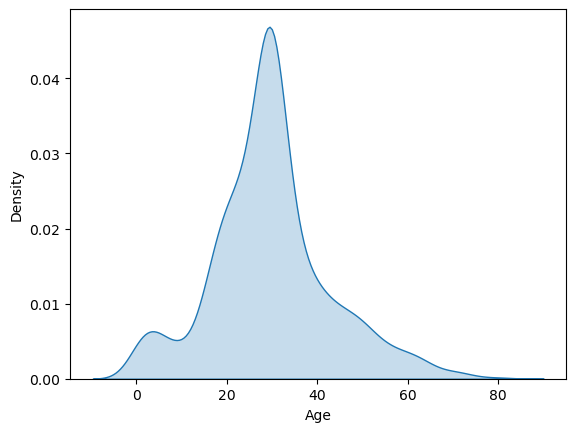

In [19]:
sns.kdeplot(train_set['Age'], fill=True)

In [20]:
train_set['Age'].skew()

np.float64(0.4344880940129925)

<Axes: xlabel='Survived', ylabel='percent'>

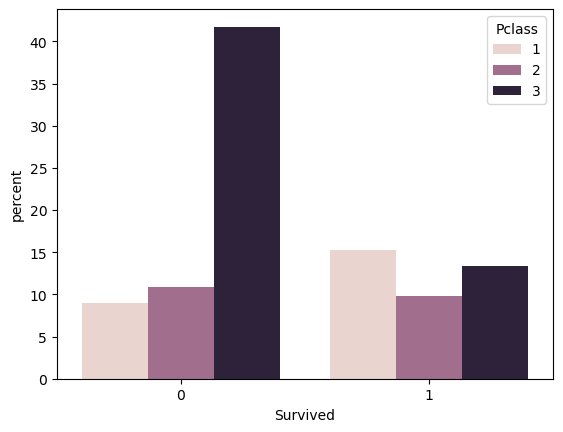

In [61]:
sns.countplot(data=train_set, x="Survived", hue="Pclass", stat="percent")


(342, 11)
28.549778121775027
29.69911764705882


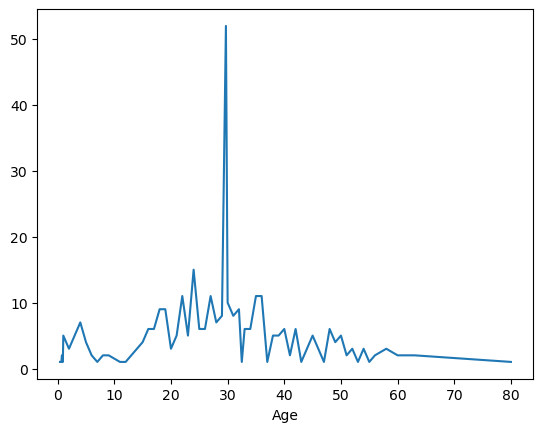

In [45]:
train_set["Survived"].value_counts()
train_set["Age"].value_counts()
survive_set = train_set.loc[train_set["Survived"]==1]
print(survive_set.shape)
survive_set["Age"].value_counts().sort_index(ascending=True).plot()
print(survive_set["Age"].mean())
print(train_set["Age"].mean())

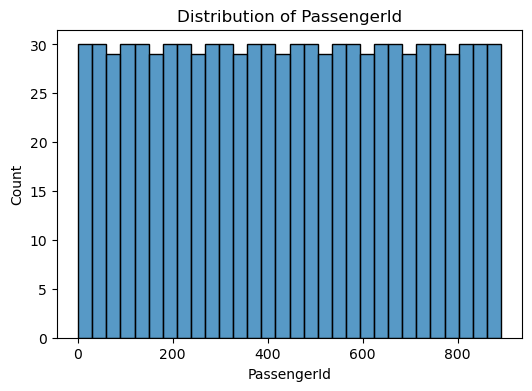

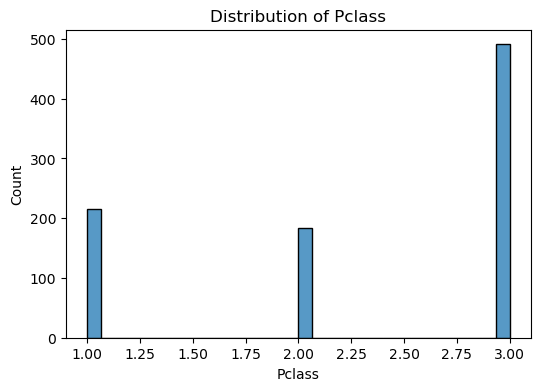

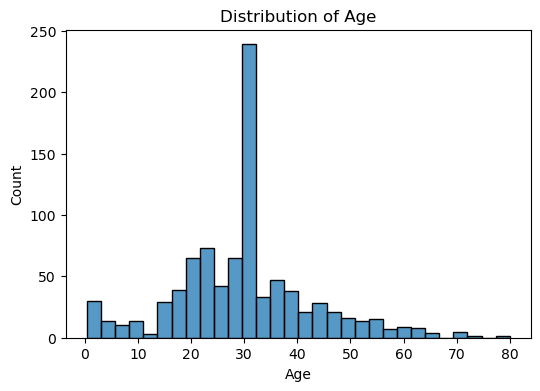

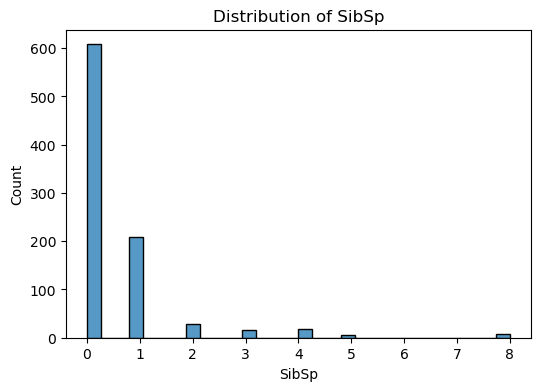

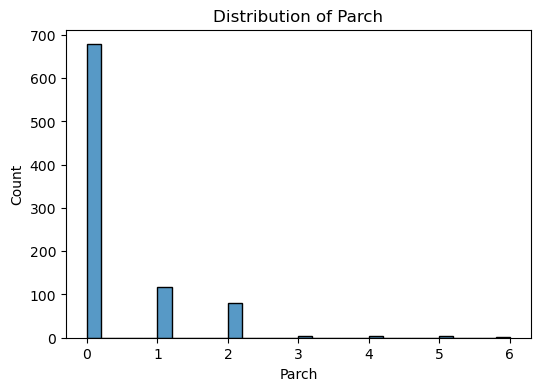

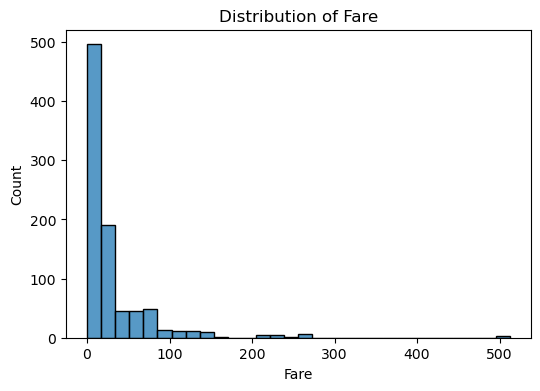

In [31]:
### Histograms 
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(train_set[col], kde=False, bins=30)
    plt.title(f'Distribution of {col}')
    plt.show()

<Axes: >

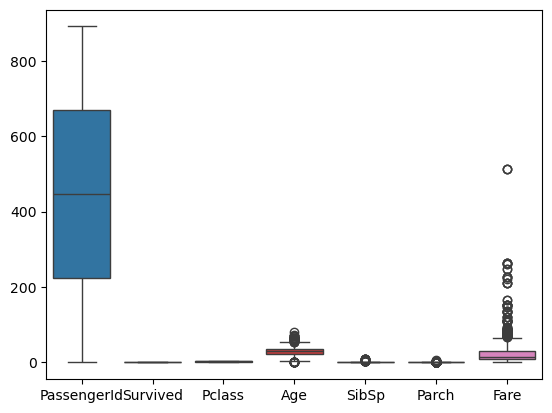

In [22]:
#Boxplot
sns.boxplot(data=train_set)

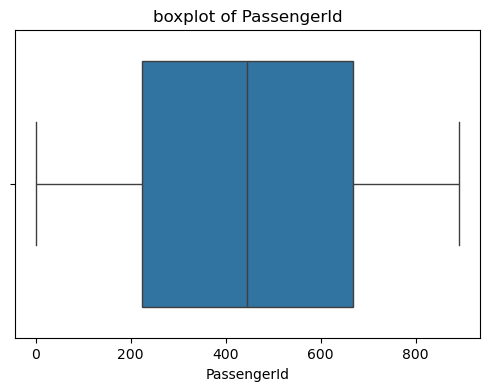

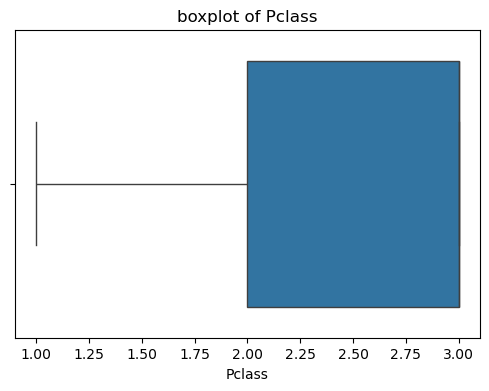

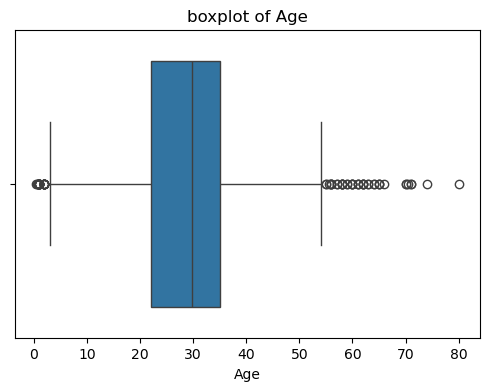

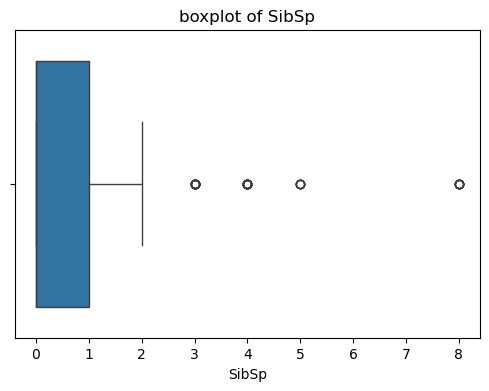

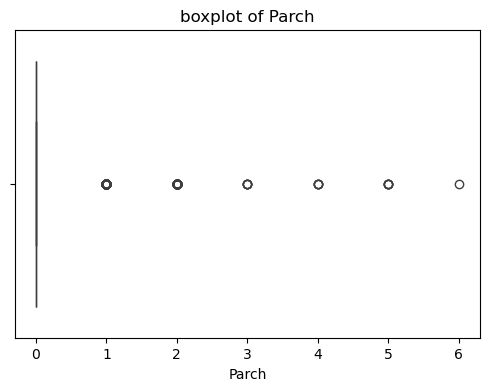

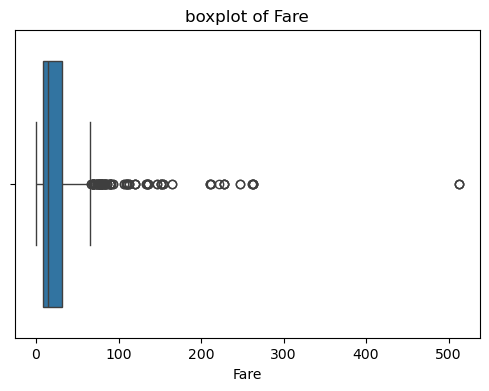

In [23]:
#### Boxplots
for col in num_cols :
  plt.figure(figsize = (6,4))
  sns.boxplot(x=train_set[col])
  plt.title(f'boxplot of {col}')
  plt.show()

In [24]:
### Outlier detection using IQR
for col in num_cols :
    q1 = train_set[col].quantile(0.25)
    q3 = train_set[col].quantile(0.75)
    iqr = q3 - q1
    outliers = train_set[(train_set < q1 - 1.5*iqr) | (train_set > q3 - 1.5*iqr)]
    print(f'number of outliers for {col} is {len(outliers)}')
    

UFuncTypeError: ufunc 'greater' did not contain a loop with signature matching types (<class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.StrDType'>) -> None

In [ ]:
# Bivariate analysis
## Numerical features
for col in cat_cols :
    sns.boxplot(x=train_set['target'], y=train_set[col])
    plt.title(f"{col} vs target")
    plt.show()

In [ ]:
## Categorical features
for col in cat_cols :
    ct = pd.crosstab(train_set[col], train_set['S'], normalize='index')
    print(ct)
    ct.plot(kind='bar', stacked=True)
    plt.title(f'{col} vs target')
    plt.show()

KeyError: 'target'

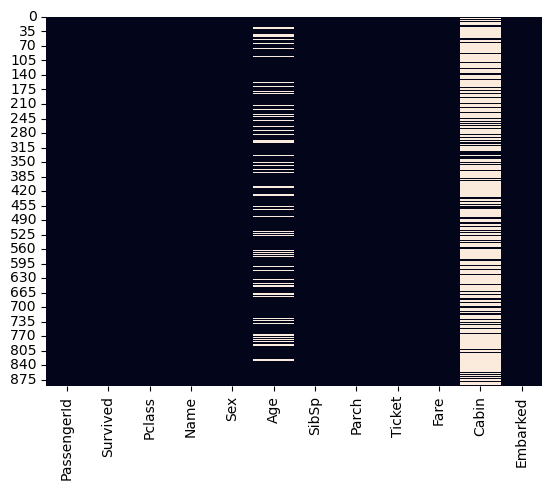

In [ ]:
sns.heatmap(train_set.isnull(), cbar=False)
plt.show()

In [ ]:
train_set.describe(percentiles=[0.01, 0.99]).T

,count,mean,std,min,1%,50%,99%,max
PassengerId,891.0,446.000000,257.353842,1.00,9.9,446.0000,882.10000,891.0000
Survived,891.0,0.383838,0.486592,0.00,0.0,0.0000,1.00000,1.0000
Pclass,891.0,2.308642,0.836071,1.00,1.0,3.0000,3.00000,3.0000
Age,714.0,29.699118,14.526497,0.42,1.0,28.0000,65.87000,80.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0,0.0000,5.00000,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0,0.0000,4.00000,6.0000
Fare,891.0,32.204208,49.693429,0.00,0.0,14.4542,249.00622,512.3292


In [ ]:
def iqr_outliers(series) :
  q1, q3 = series.quantile([0.25, 0.75])
  iqr = q3 - q1
  print(q1 - 1.5*iqr)
  print(q3 + 1.5*iqr)
  print(q3)
  return series[(series < q1 -1.5*iqr) | (series > q3 + 1.5*iqr)]

outliers = iqr_outliers(train_set['Age'])
print(len(outliers)/train_set.shape[0])


-6.6875
64.8125
38.0
0.012345679012345678


<Axes: >

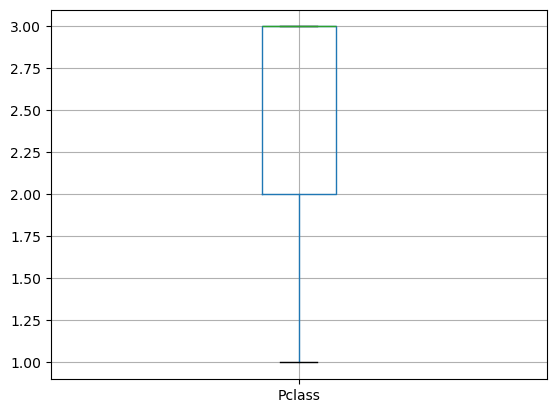

In [ ]:
train_set.boxplot(column='Pclass')

In [ ]:
train_set[['Pclass']].boxplot()

In [ ]:
#Preprocessing


In [ ]:
#Feature engineering

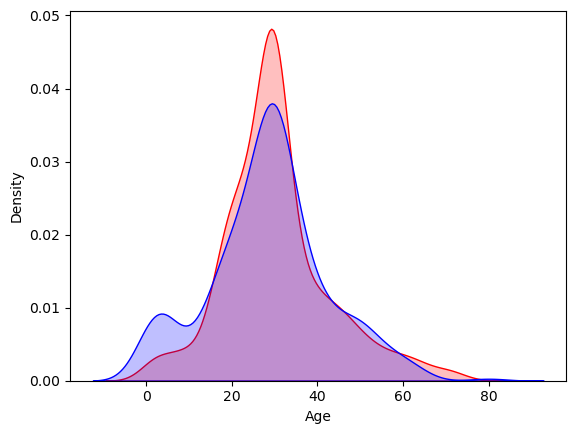

In [ ]:
plot = sns.kdeplot(train_set.loc[train_set["Survived"]==0].Age, color='red', fill=True)
plot = sns.kdeplot(train_set.Age[(train_set["Survived"]==1)], color='blue', fill=True)


In [40]:
corr_matrix = train_set[num_cols].corr()
print(corr_matrix.index.tolist())
print(corr_matrix.columns.tolist())
# corr_matrix["Pclass"].sort_values(ascending=False).plot(kind='bar')
# sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
# corr_matrix["Pclass"].sort_values(ascending=False).plot(kind='bar')
# sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')

['PassengerId', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
['PassengerId', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']


<Axes: xlabel='Age'>

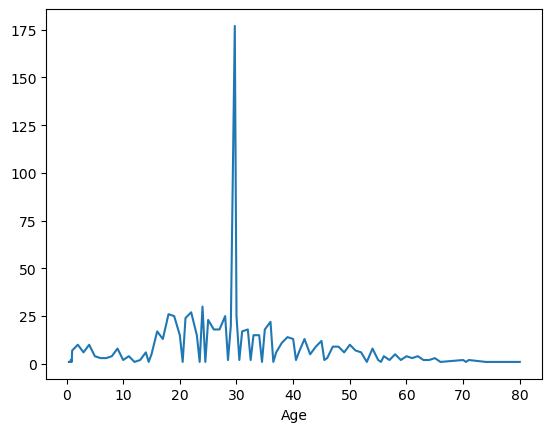

In [42]:
train_set["Age"].value_counts().sort_index(ascending=True).plot()

In [ ]:
pd.crosstab(train_set[])

SyntaxError: invalid syntax. Perhaps you forgot a comma? (3783860150.py, line 1)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform((X_train))
X_test_scaled = scaler.fit_transform(X_test)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metric import classification_report, roc_auc_score

#-------- separate features and target
X = train_set.drop(columns = ['Survived'])
y = train_set['Survived']

#-------- train/validation split
X_train, y_train, X_val, y_val = train_test_split(
    X, y,
    test_size = 0.2,
    stratify = y,
    random_state = 42 
)


model = Pipeline(steps = [
                        ("scaler", StandardScaler()), 
                        ("clf",LogisticRegression(
                            max_iter=1000,
                            class_weight="balanced",
                            random_state=42))
])


model.fit(X_train, y_train)

y_pred = model.predict(X_val)
y_proba = model.predict_proba(X_val)[:,1]

print(classification_report(y_val, y_pred))
print("ROC AUC :",roc_auc_score(y_val, y_proba))


In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    m_enstimators=300,
    max_depth=8,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=1
)

model.fit(X_train, y_train)
y_pred = model.predict(y_val)


In [ ]:
import optuna

def objective(trial) :
    params = {
        "n_estimators" : trial.suggest_int("n_estimators" : 100, 600),
        "max_depth" : trial.suggest_int("max_depth" : 3, 20),
        "min_samples_split" : trial.suggest_int("min_samples_split" : 2, 200),
        "min_samples_leaf" : trial.suggest_int("min_samples_leaf" : 2, 23),
        "max_features" : trial.suggest_categorical("max_features" : 2, 30),
        "random_state" : 42,
        "n_jobs" : -1
    }

    model = RandomForestClassifier(** params)

    score = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="roc_auc",
        n_jobs=-1
    ).mean()

    return score





In [ ]:
from sklearn.preprocessing import MinMaxScaler

df = pd.DataFrame(train_set, columns=['Age', 'Fare'])
scaler = MinMaxScaler()
scaled_value = scaler.fit_transform(df)
scaled_value.head()

NameError: name 'train_set' is not defined

In [ ]:
scaler = StandardScaler()

import statistics as st


In [ ]:
# Funtion to detect outliers using the 